# Access the analysis ready CERRA single levels data

This notebook provides an example of how to open the reanalysis-cerra-single-levels Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked analysis data (optimised for time-series at a single location)
geochunked_analysis_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-046/arco/reanalysis_cerra_single_levels/analysis/geoChunked.zarr"

# Time-chunked analysis data (optimised for map at a single time step)
timechunked_analysis_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-046/arco/reanalysis_cerra_single_levels/analysis/timeChunked.zarr"

# Geo-chunked forecast data (optimised for time-series at a single location)
geochunked_forecast_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-047/arco/reanalysis_cerra_single_levels/forecast/geoChunked.zarr"

# Time-chunked forecast data (optimised for map at a single time step)
timechunked_forecast_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-047/arco/reanalysis_cerra_single_levels/forecast/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_analysis_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 10TB
Dimensions:    (time: 121024, latitude: 1300, longitude: 2700)
Coordinates:
  * time       (time) datetime64[ns] 968kB 1984-09-01 ... 2026-01-31T21:00:00
  * latitude   (latitude) float64 10kB 15.0 15.05 15.1 ... 79.85 79.9 79.95
  * longitude  (longitude) float64 22kB -60.0 -59.95 -59.9 ... 74.85 74.9 74.95
Data variables:
    r2         (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    sp         (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    t2m        (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    tcc        (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    wdir10     (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_edition:            2
    GRIB_subCentre:          255
    history:                 2025-10-05T10:08 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             Norrkoping

Extract a point, calculate some aggregations with earthkit-transforms and then plot a time-series using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_62657/1307929859.py:11: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()


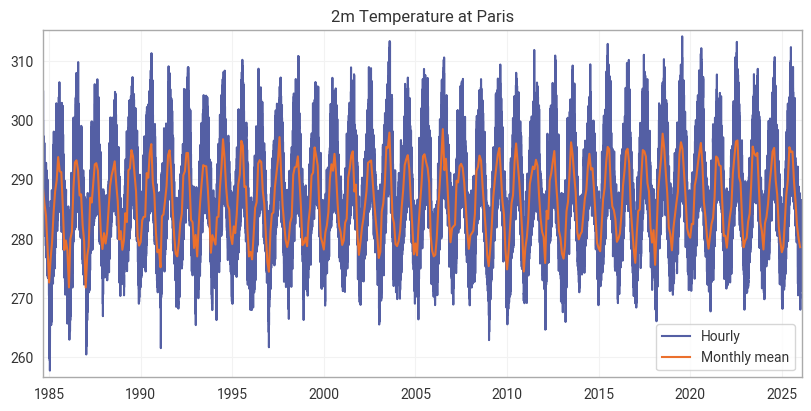

In [3]:
from earthkit import plots as ekp
from earthkit import transforms as ekt

# Select variable to plot
variable_name = "t2m"
plot_data_hourly = ds[variable_name].sel(
    latitude=48.85, longitude=2.35, method="nearest"
)
plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

chart = ekp.TimeSeries()

chart.line(plot_data_hourly, label="Hourly")
chart.line(plot_data_monthly, label="Monthly mean")

chart.title("2m Temperature at Paris")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [5]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked analysis data (optimised for time-series at a single location)
geochunked_analysis_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-046/arco/reanalysis_cerra_single_levels/analysis/geoChunked.zarr"

# Time-chunked analysis data (optimised for map at a single time step)
timechunked_analysis_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-046/arco/reanalysis_cerra_single_levels/analysis/timeChunked.zarr"

# Geo-chunked forecast data (optimised for time-series at a single location)
geochunked_forecast_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-047/arco/reanalysis_cerra_single_levels/forecast/geoChunked.zarr"

# Time-chunked forecast data (optimised for map at a single time step)
timechunked_forecast_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-047/arco/reanalysis_cerra_single_levels/forecast/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_analysis_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 10TB
Dimensions:    (time: 121024, latitude: 1300, longitude: 2700)
Coordinates:
  * time       (time) datetime64[ns] 968kB 1984-09-01 ... 2026-01-31T21:00:00
  * latitude   (latitude) float64 10kB 15.0 15.05 15.1 ... 79.85 79.9 79.95
  * longitude  (longitude) float64 22kB -60.0 -59.95 -59.9 ... 74.85 74.9 74.95
Data variables:
    r2         (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    sp         (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    t2m        (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    tcc        (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    wdir10     (time, latitude, longitude) float32 2TB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_edition:            2
    GRIB_subCentre:          255
    history:                 2025-10-05T10:08 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             Norrkoping

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.